# **Libraries**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# **Data Collecting**

In [3]:
df = pd.read_csv('../../data/synthetic_data.csv')
df = df.set_index("timestamp_prediction")
df = df.sort_index()

In [4]:
df.head(10)

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2025-01-01 06:00:00,Kramat Jati,777,Tipe 4,316949,9344,2,0,0,2.50,20.0,0.0,10.66,65.31
2025-01-01 06:00:00,Tanjung Priok,971,Tipe 2,418090,1064,2,0,0,2.41,4.9,2.4,18.88,76.71
2025-01-01 06:00:00,Taman Sari,179,Tipe 4,109430,5047,2,0,0,1.84,4.9,0.0,16.94,34.46
2025-01-01 06:00:00,Tebet,747,Tipe 1,222340,2252,2,0,0,2.14,15.4,0.0,21.85,69.05
2025-01-01 06:00:00,Gambir,554,Tipe 4,90638,8671,2,0,0,2.02,4.9,0.0,9.24,17.95
2025-01-01 06:00:00,Cakung,593,Tipe 3R,582666,8874,2,0,0,2.01,14.0,0.0,9.06,82.81
2025-01-01 06:00:00,Tanah Abang,1275,Tipe 4,165179,6628,2,0,1,0.64,4.9,0.0,10.65,53.50
2025-01-01 06:00:00,Jagakarsa,4,Tipe 4,387458,7932,2,0,0,1.74,32.8,0.0,17.86,87.47
2025-01-01 06:00:00,Ciracas,1069,Tipe 4,319395,6534,2,0,0,2.79,20.0,0.0,19.94,69.90


In [5]:
df[df["tps_id"] == 700]

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2025-01-01 06:00:00,Pulogadung,700,Tipe 4,296845,7180,2,0,0,0.73,15.4,0.0,16.71,57.24
2025-01-02 06:00:00,Pulogadung,700,Tipe 4,296845,7180,3,0,0,0.53,0.6,0.0,57.77,111.06
2025-01-03 06:00:00,Pulogadung,700,Tipe 4,296845,7180,4,0,0,0.78,2.2,0.0,9.48,50.35
2025-01-04 06:00:00,Pulogadung,700,Tipe 4,296845,7180,5,1,0,2.86,1.1,0.0,53.21,107.66
2025-01-05 06:00:00,Pulogadung,700,Tipe 4,296845,7180,6,1,0,1.89,18.5,0.0,9.92,64.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26 06:00:00,Pulogadung,700,Tipe 4,296845,7180,4,0,0,1.28,1.2,0.0,6.71,64.79
2026-06-27 06:00:00,Pulogadung,700,Tipe 4,296845,7180,5,1,0,2.01,1.3,0.0,11.33,69.66
2026-06-28 06:00:00,Pulogadung,700,Tipe 4,296845,7180,6,1,0,1.72,1.8,0.0,11.46,68.74


# **Exploratory Data Analysis**

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 704886 entries, 2025-01-01 06:00:00 to 2026-06-30 06:00:00
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   kecamatan                704886 non-null  str    
 1   tps_id                   704886 non-null  int64  
 2   tps_type                 704886 non-null  str    
 3   zone_population          704886 non-null  int64  
 4   tps_capacity_kg          704886 non-null  int64  
 5   day_of_week              704886 non-null  int64  
 6   is_weekend               704886 non-null  int64  
 7   is_holiday               704886 non-null  int64  
 8   daily_growth_rate        704886 non-null  float64
 9   rainfall_today           704886 non-null  float64
 10  event_urgency_score      704886 non-null  float64
 11  current_fill_percentage  704886 non-null  float64
 12  target_fill_percentage   704886 non-null  float64
dtypes: float64(5), int64(6), str(2)
memory usage

In [7]:
df.duplicated().sum()

0

In [8]:
df.isna().sum()

kecamatan                  0
tps_id                     0
tps_type                   0
zone_population            0
tps_capacity_kg            0
day_of_week                0
is_weekend                 0
is_holiday                 0
daily_growth_rate          0
rainfall_today             0
event_urgency_score        0
current_fill_percentage    0
target_fill_percentage     0
dtype: int64

In [9]:
df.nunique()

kecamatan                     42
tps_id                      1291
tps_type                       7
zone_population               42
tps_capacity_kg             1188
day_of_week                    7
is_weekend                     2
is_holiday                     2
daily_growth_rate            251
rainfall_today               443
event_urgency_score           32
current_fill_percentage     5734
target_fill_percentage     10616
dtype: int64

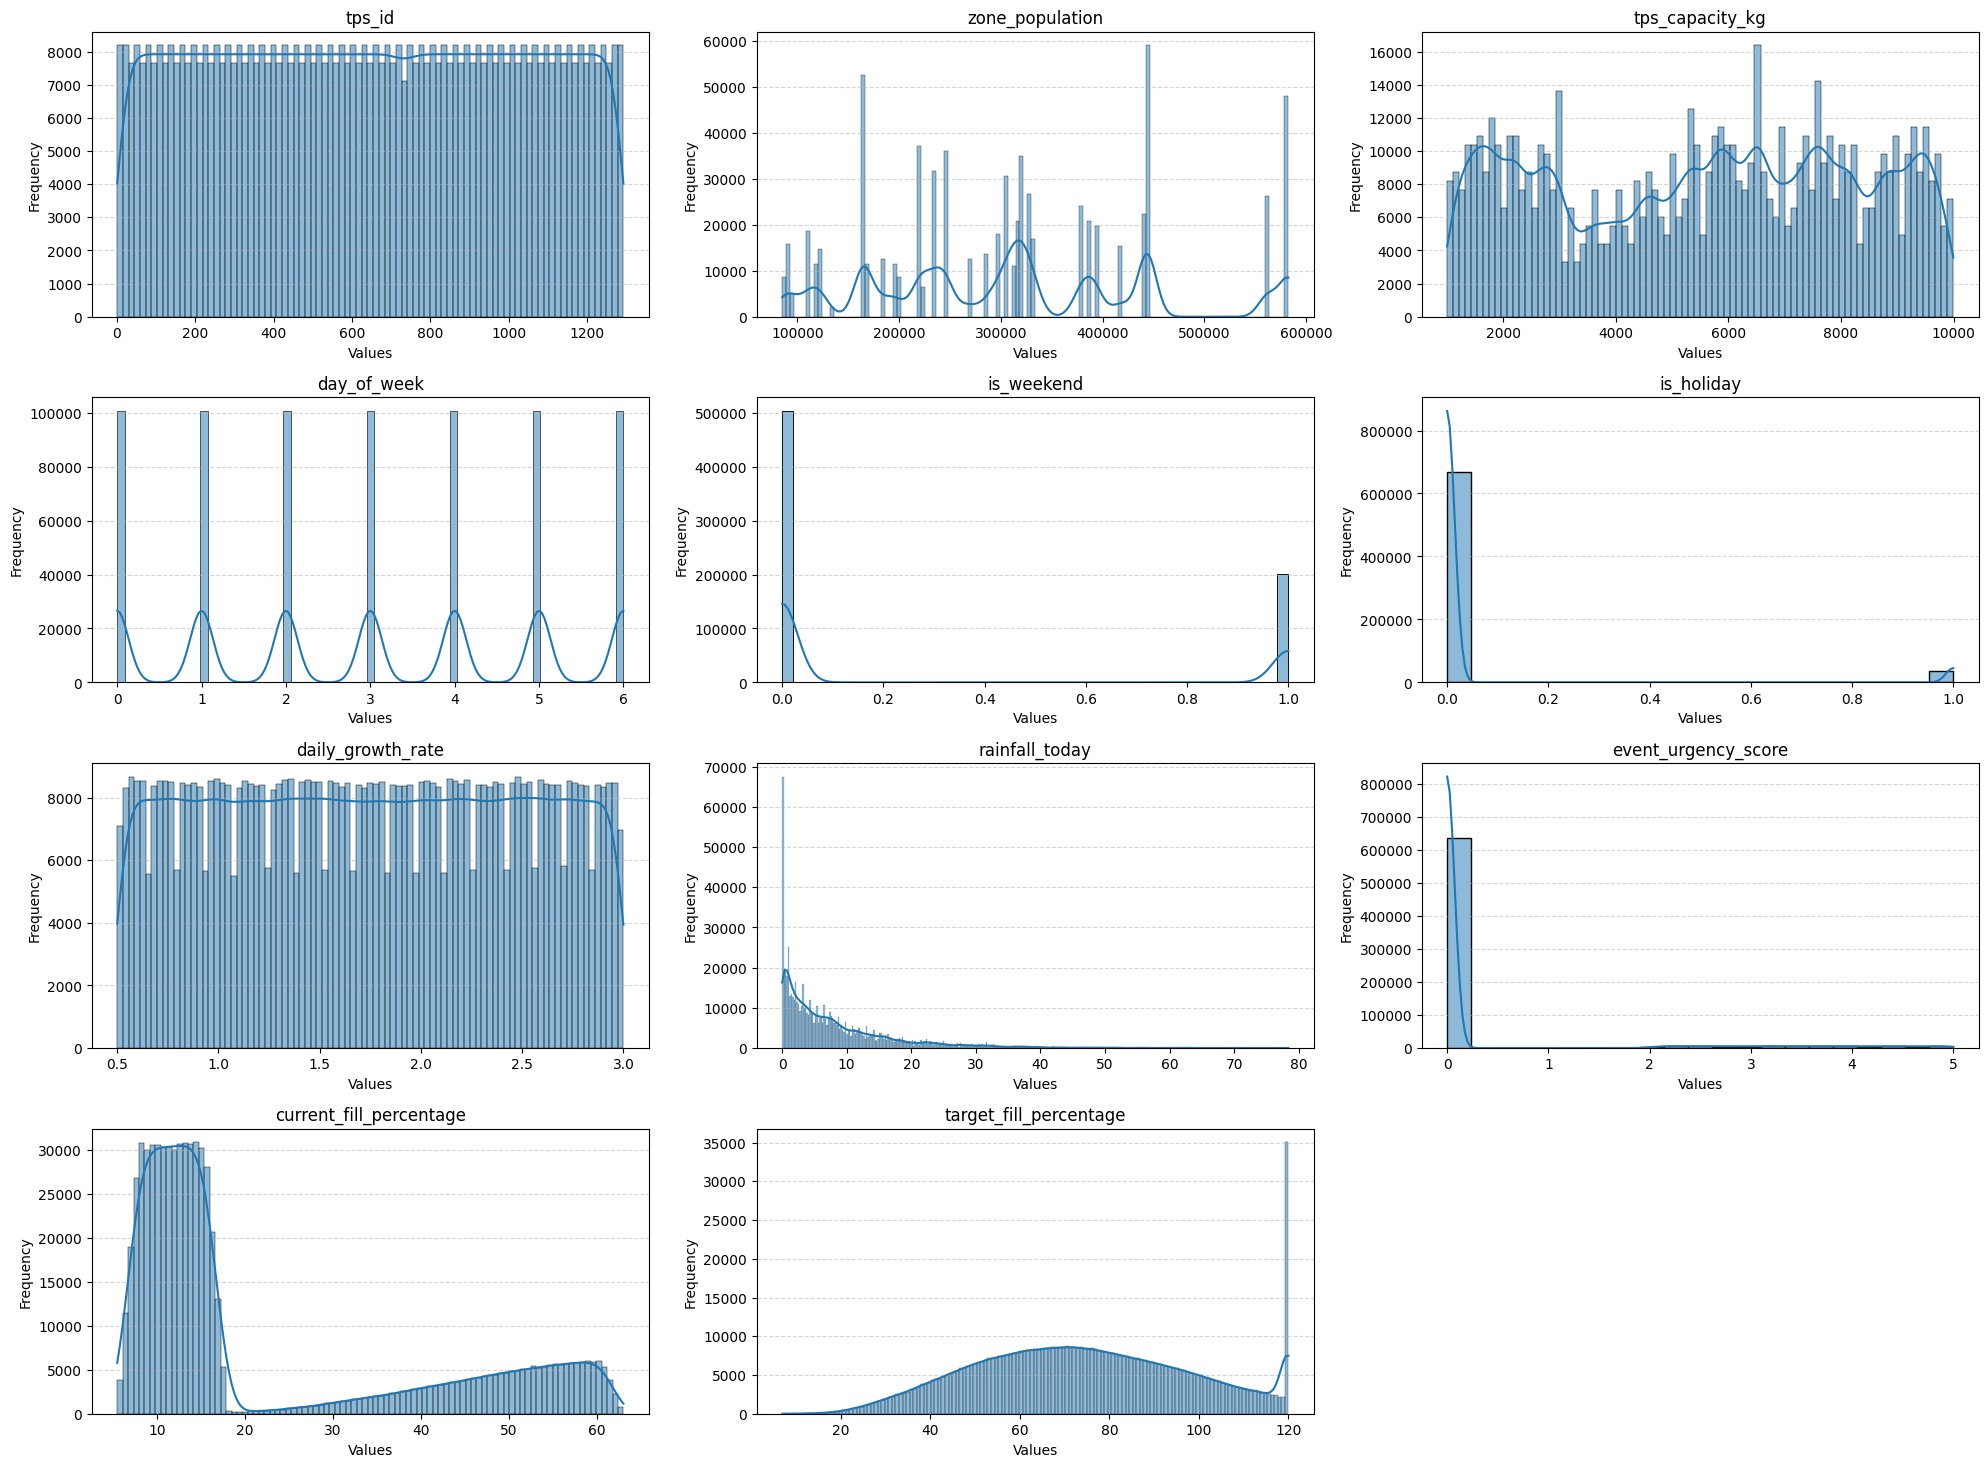

In [10]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=ax[i], kde=True)
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")
    ax[i].grid(axis='y', alpha=0.5, linestyle='--')


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

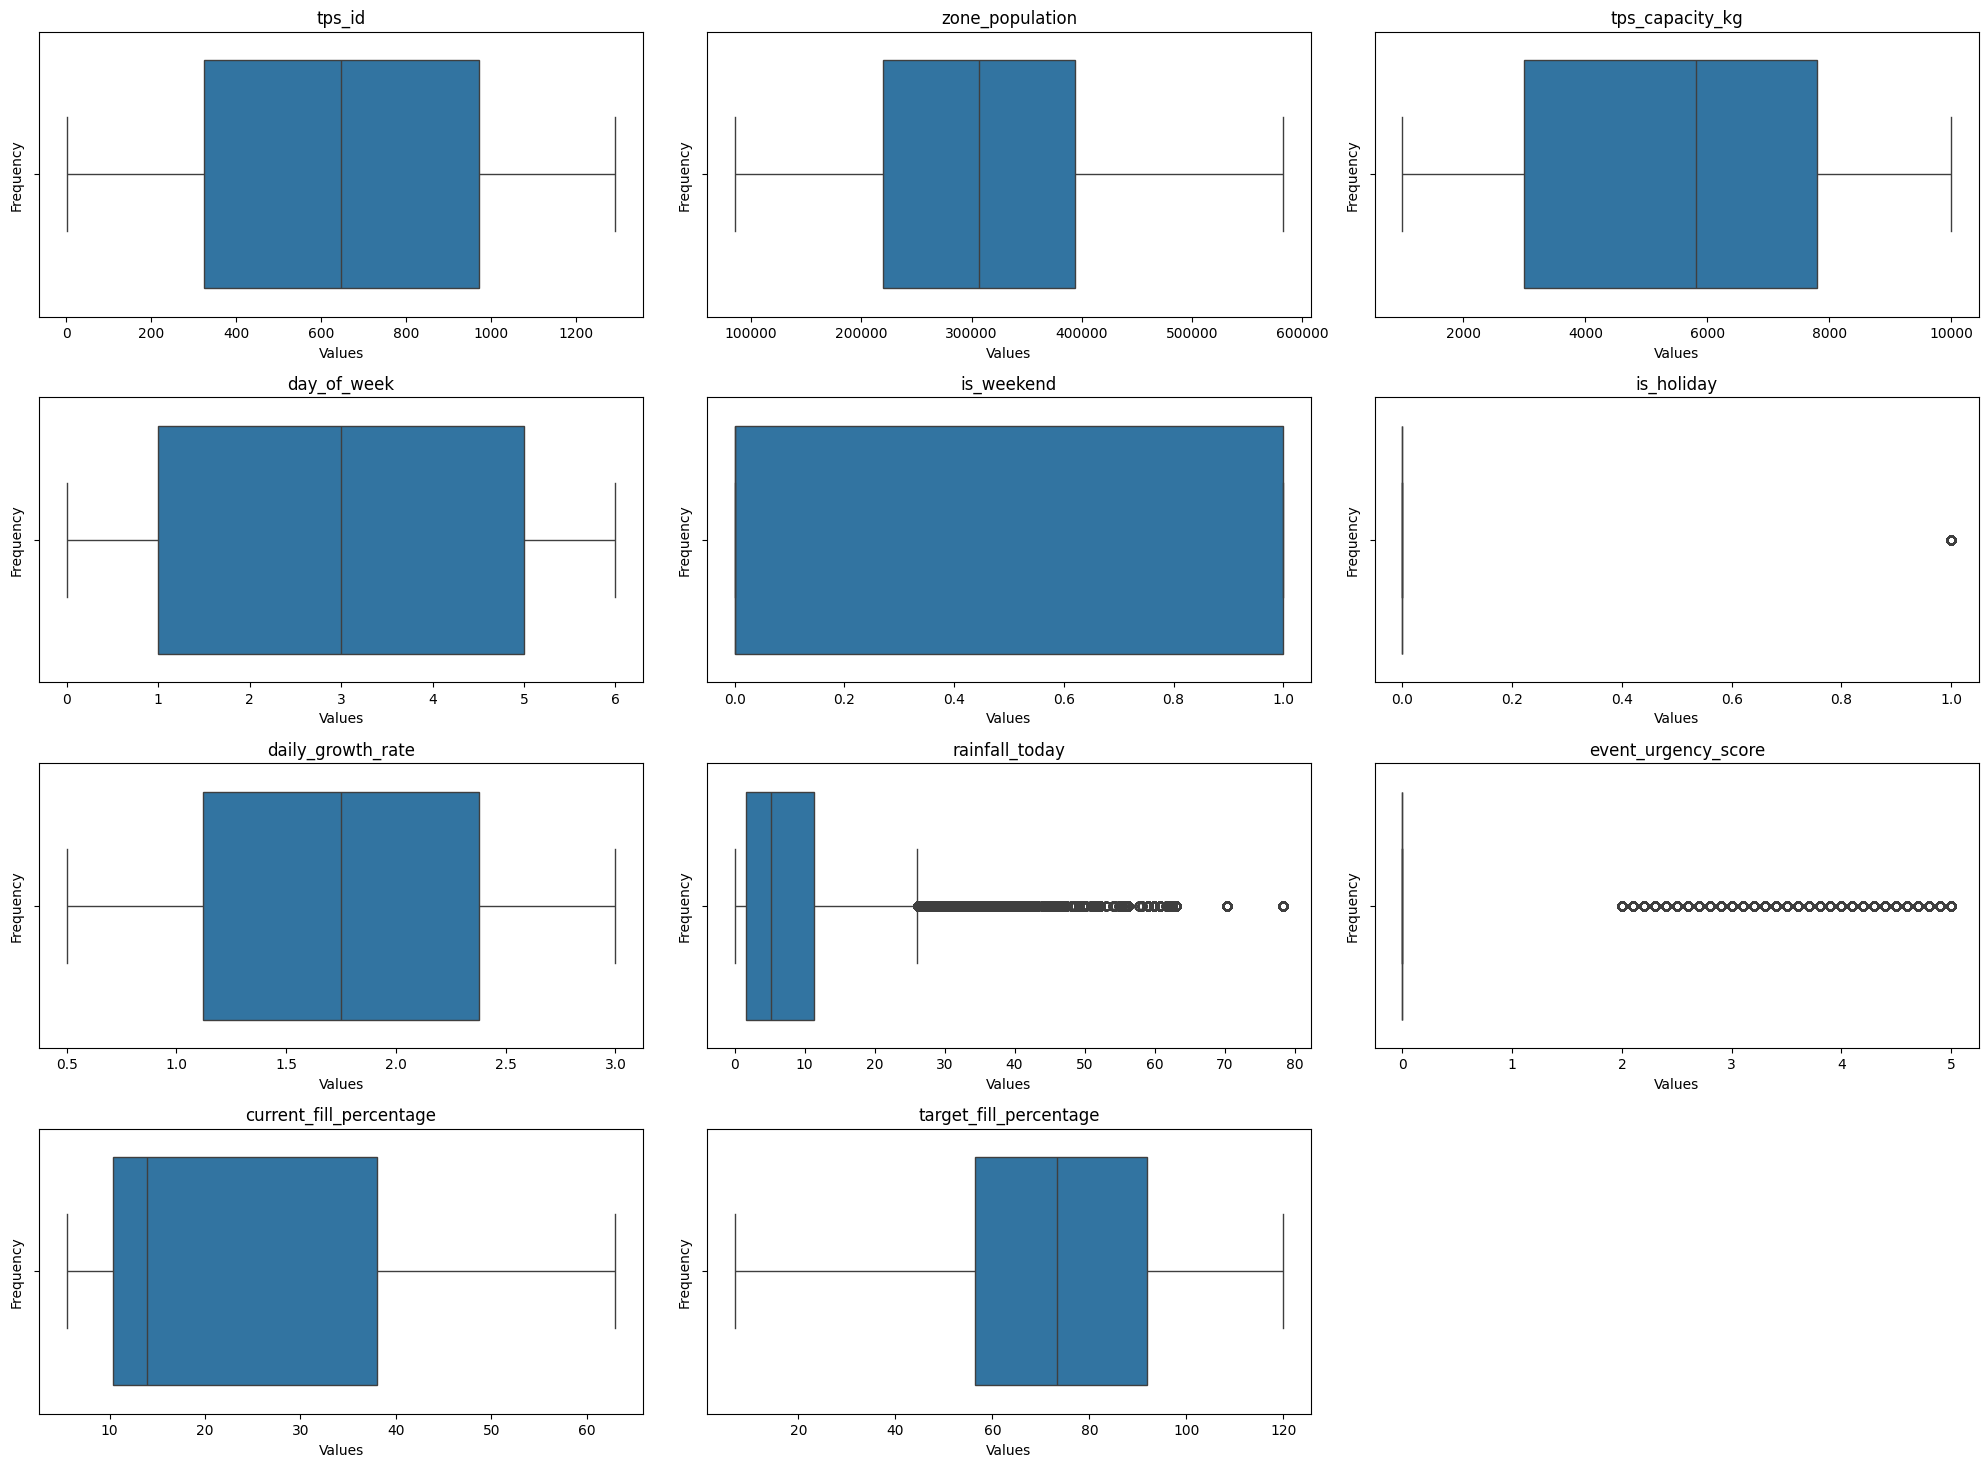

In [11]:
fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(df[col], ax=ax[i], orient="h")
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

In [12]:
print(df["kecamatan"].unique())

<StringArray>
[      'Kramat Jati',     'Tanjung Priok',        'Taman Sari',
             'Tebet',            'Gambir',            'Cakung',
       'Tanah Abang',         'Jagakarsa',           'Ciracas',
          'Cipayung',           'Tambora',        'Pulogadung',
          'Pancoran',         'Kemayoran',       'Penjaringan',
       'Duren Sawit',        'Pasar Rebo',         'Kalideres',
       'Kebon Jeruk',             'Senen',        'Cengkareng',
  'Mampang Prapatan',           'Makasar',      'Pasar Minggu',
      'Pesanggrahan',              'Koja', 'Grogol Petamburan',
           'Menteng',          'Palmerah',         'Cilincing',
     'Kelapa Gading',          'Cilandak',        'Jatinegara',
          'Matraman',        'Pademangan',    'Kebayoran Lama',
    'Kebayoran Baru',         'Kembangan',         'Setiabudi',
       'Sawah Besar',     'Cempaka Putih',        'Johar Baru']
Length: 42, dtype: str


In [13]:
for i in df["tps_id"].unique():
    tps_id = i

    capacity = df.groupby("tps_id")["tps_capacity_kg"]

In [9]:
tps_capacity_dict = df.groupby("tps_id")["tps_capacity_kg"].first().to_dict()

with open("../../data/tps_capacity.py", "w", encoding="utf-8") as f:
    f.write("TPS_CAPACITY = ")
    f.write(repr(tps_capacity_dict))

print("TPS_CAPACITY saved to dictionary file.")

TPS_CAPACITY saved to dictionary file.


In [8]:
zone_population_dict = df.groupby("kecamatan")["zone_population"].first().to_dict()

with open("../../data/zone_population.py", "w", encoding="utf-8") as f:
    f.write("ZONE_POPULATION = ")
    f.write(repr(zone_population_dict))

print("ZONE_POPULATION saved to dictionary file.")

ZONE_POPULATION saved to dictionary file.


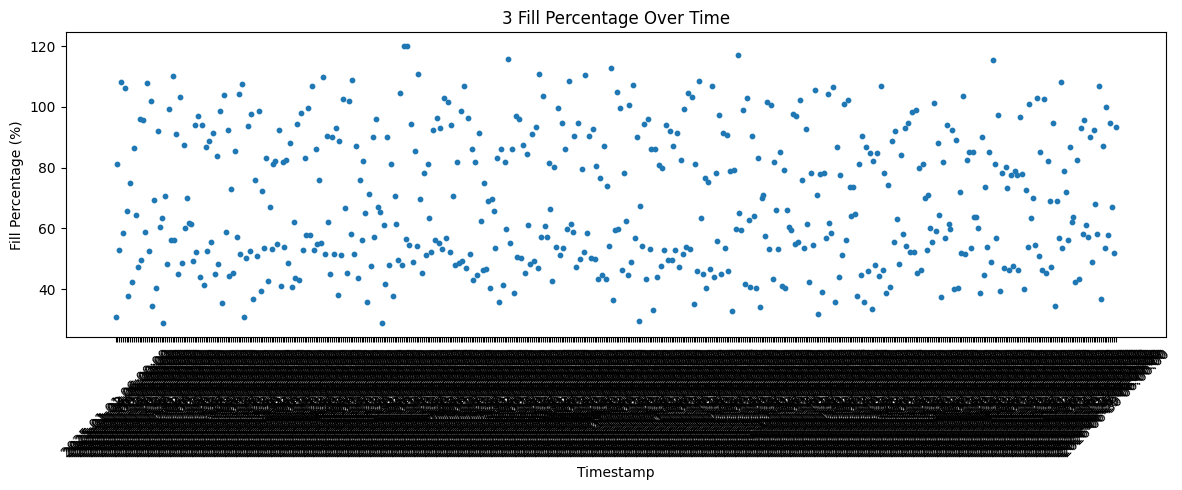

In [15]:
subset = df[df["tps_id"] == 3]

plt.figure(figsize=(12, 5))

plt.scatter(
    subset.index,
    subset["target_fill_percentage"],
    s=10  # dot size
)

plt.xlabel("Timestamp")
plt.ylabel("Fill Percentage (%)")
plt.title(f"{subset['tps_id'].iloc[0]} Fill Percentage Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [16]:
preproc_df = df.copy()
preproc_df.tail()

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2026-06-30 06:00:00,Cilincing,172,Tipe 4,444380,8704,1,0,0,2.97,0.5,0.0,58.24,120.00
2026-06-30 06:00:00,Cakung,977,Door To Door,582666,9156,1,0,0,2.75,0.2,0.0,12.31,111.68
2026-06-30 06:00:00,Cilincing,171,Lintas,444380,6215,1,0,0,0.51,0.5,0.0,8.21,100.97
2026-06-30 06:00:00,Taman Sari,170,Tipe 4,109430,8890,1,0,0,2.19,0.1,0.0,54.69,58.50
2026-06-30 06:00:00,Pasar Rebo,1292,Tipe 4,235825,6883,1,0,0,0.80,0.7,3.7,38.83,86.85


## **Train Test Split**

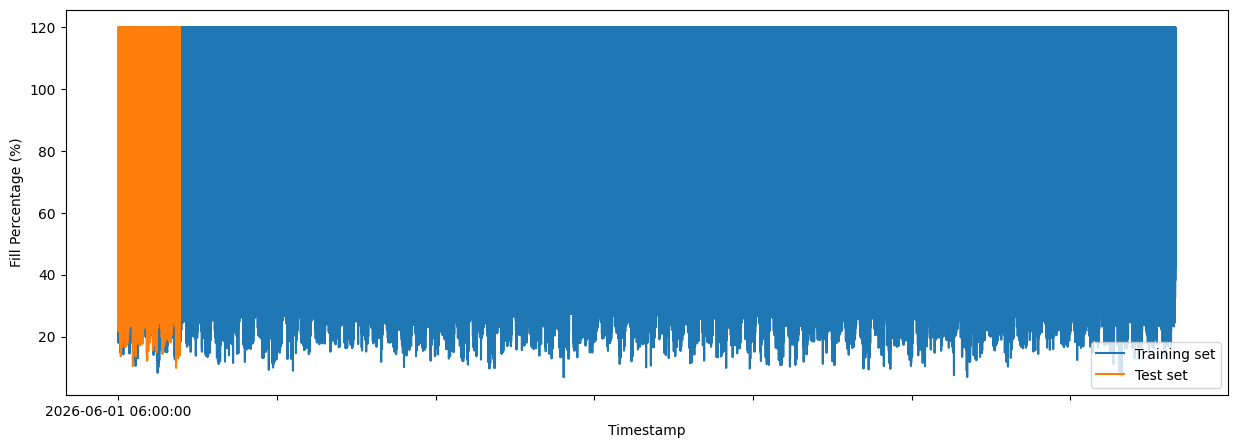

In [17]:
train = preproc_df.loc[preproc_df.index <= "2026-05-31 06:00:00"]
test = preproc_df.loc[preproc_df.index > "2026-05-31 06:00:00"]

fig, ax = plt.subplots(figsize=(15,5))
train["target_fill_percentage"].plot(ax=ax, label="Training set")
test["target_fill_percentage"].plot(ax=ax, label="Test set")

ax.set_xlabel("Timestamp")
ax.set_ylabel("Fill Percentage (%)")
ax.legend()

plt.show()

## **Label Encoding**

In [16]:
encoders = joblib.load("encoders.pkl")

for col, encoder in encoders.items():
    print(f"\n=== {col} ===")
    for i, label in enumerate(encoder.classes_):
        print(f"{label} -> {i}")


=== kecamatan ===
Cakung -> 0
Cempaka Putih -> 1
Cengkareng -> 2
Cilandak -> 3
Cilincing -> 4
Cipayung -> 5
Ciracas -> 6
Duren Sawit -> 7
Gambir -> 8
Grogol Petamburan -> 9
Jagakarsa -> 10
Jatinegara -> 11
Johar Baru -> 12
Kalideres -> 13
Kebayoran Baru -> 14
Kebayoran Lama -> 15
Kebon Jeruk -> 16
Kelapa Gading -> 17
Kemayoran -> 18
Kembangan -> 19
Koja -> 20
Kramat Jati -> 21
Makasar -> 22
Mampang Prapatan -> 23
Matraman -> 24
Menteng -> 25
Pademangan -> 26
Palmerah -> 27
Pancoran -> 28
Pasar Minggu -> 29
Pasar Rebo -> 30
Penjaringan -> 31
Pesanggrahan -> 32
Pulogadung -> 33
Sawah Besar -> 34
Senen -> 35
Setiabudi -> 36
Taman Sari -> 37
Tambora -> 38
Tanah Abang -> 39
Tanjung Priok -> 40
Tebet -> 41

=== tps_type ===
Door To Door -> 0
Lintas -> 1
Tipe 1 -> 2
Tipe 2 -> 3
Tipe 3 -> 4
Tipe 3R -> 5
Tipe 4 -> 6


In [22]:
encoding_cols = [
    "kecamatan",
    "tps_type"
]

encoders = {}

for col in encoding_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

In [23]:
train.dtypes

kecamatan                    int32
tps_id                       int64
tps_type                     int32
zone_population              int64
tps_capacity_kg              int64
day_of_week                  int64
is_weekend                   int64
is_holiday                   int64
daily_growth_rate          float64
rainfall_today             float64
event_urgency_score        float64
current_fill_percentage    float64
target_fill_percentage     float64
dtype: object

In [24]:
for col in encoding_cols:
    le = encoders[col]
    test[col] = le.transform(test[col])

In [25]:
for col in encoding_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    print(col, unseen)

kecamatan set()
tps_type set()


In [26]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

## **Split into X and y**

In [27]:
TARGET = "target_fill_percentage"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(666156, 12)
(38730, 12)
(666156,)
(38730,)


# **Training**

In [24]:
models = {
    # "Random Forest Regressor": (
    #     RandomForestRegressor(random_state=42), 
    #     {
    #         "n_estimators": [100, 200],
    #         "max_depth": [10, None],
    #         "min_samples_split": [2, 4],
    #         "min_samples_leaf": [1, 2],
    #     }
    # ),

    # "Gradient Boosting Regressor": (
    #     GradientBoostingRegressor(random_state=42),
    #     {
    #         "n_estimators": [100, 200],
    #         "learning_rate": [0.01, 0.05, 0.1],
    #         "max_depth": [5, 7, 9],
    #         "subsample": [0.8, 1.0]
    #     }
    # )

    "XGBoost": (
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="mae",
            early_stopping_rounds=30
        ),
        {
            "n_estimators": [300, 500],
            "learning_rate": [0.05, 0.1],
            "max_depth": [6, 8],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 3],
        }
    )
}

In [25]:
timeseriescv = TimeSeriesSplit(n_splits=5)

In [26]:
%%time

results = []

for name, (model, params) in models.items():
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,
        cv=timeseriescv,
        scoring="neg_mean_absolute_error",
        n_jobs=6,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=50)

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R2": r2,
        "Best Params": search.best_params_,
        "Best CV Score": -search.best_score_,
        "Estimator": best_model
    })

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[0]	validation_0-mae:19.07609	validation_1-mae:18.95692
[50]	validation_0-mae:8.47600	validation_1-mae:8.45276
[100]	validation_0-mae:8.11413	validation_1-mae:8.12358
[150]	validation_0-mae:8.08244	validation_1-mae:8.10330
[200]	validation_0-mae:8.07024	validation_1-mae:8.10085
[241]	validation_0-mae:8.06160	validation_1-mae:8.10084
CPU times: total: 1min 17s
Wall time: 6min 4s


In [27]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAE")

results_df

,Model,MAE,MAPE,RMSE,R2,Best Params,Best CV Score,Estimator
0,XGBoost,8.100529,0.117582,10.106534,0.820969,"{'subsample': 0.8, 'n_estimators': 500, 'min_c...",8.11768,"XGBRegressor(base_score=None, booster=None, ca..."


In [28]:
best_result = min(results, key=lambda x: x["MAE"])

best_model = best_result["Estimator"]

print(best_result["Model"])

print(best_result["Best Params"])

XGBoost
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [29]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
3,zone_population,0.482392
11,current_fill_percentage,0.267187
0,kecamatan,0.118967
10,event_urgency_score,0.048294
5,day_of_week,0.038143
7,is_holiday,0.037021
9,rainfall_today,0.006180
4,tps_capacity_kg,0.000469
1,tps_id,0.000468
8,daily_growth_rate,0.000467


In [30]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train acc:", r2_score(y_train, train_pred))
print("Test acc:", r2_score(y_test, test_pred))

Train acc: 0.8243701796304335
Test acc: 0.8209689971797922


In [31]:
X_train.columns

Index(['kecamatan', 'tps_id', 'tps_type', 'zone_population', 'tps_capacity_kg',
       'day_of_week', 'is_weekend', 'is_holiday', 'daily_growth_rate',
       'rainfall_today', 'event_urgency_score', 'current_fill_percentage'],
      dtype='str')

In [32]:
y_pred = best_model.predict(X_test)

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
}, index=y_test.index)

In [33]:
joblib.dump(best_model, "forecast_waste_volume_model.pkl")

['forecast_waste_volume_model.pkl']

In [34]:
train_data = X_train.copy()
train_data["target_fill_percentage"] = y_train

train_data.to_csv("../../data/train.csv")

In [28]:
test_data = X_test.copy()
test_data["target_fill_percentage"] = y_test

for col in encoding_cols:
    test_data[col] = encoders[col].inverse_transform(test_data[col])

test_data = test_data.reset_index()

test_data.to_csv("../../data/test.csv", index=False)

In [40]:
test_data["kecamatan"].unique()

<StringArray>
[       'Jatinegara',            'Gambir',           'Makasar',
           'Tambora',       'Kebon Jeruk',          'Palmerah',
              'Koja',         'Cilincing',       'Penjaringan',
        'Pademangan',     'Cempaka Putih',             'Senen',
 'Grogol Petamburan',         'Jagakarsa',        'Pasar Rebo',
       'Tanah Abang',       'Kramat Jati',         'Kalideres',
     'Tanjung Priok',           'Ciracas',    'Kebayoran Baru',
        'Cengkareng',           'Menteng',          'Cilandak',
        'Taman Sari',          'Cipayung',         'Kembangan',
     'Kelapa Gading',      'Pasar Minggu',            'Cakung',
       'Duren Sawit',         'Kemayoran',          'Matraman',
          'Pancoran',      'Pesanggrahan',             'Tebet',
         'Setiabudi',    'Kebayoran Lama',       'Sawah Besar',
  'Mampang Prapatan',        'Pulogadung',        'Johar Baru']
Length: 42, dtype: str

In [36]:
from datetime import datetime
import pandas as pd

# ===========================
# 1. Save metadata BEFORE encoding
# ===========================
metadata_test = test[
    [
        "kecamatan",
        "tps_id"
    ]
].copy()

metadata_test["timestamp_prediction"] = test.index

# ===========================
# 2. Predict
# ===========================
preds = best_model.predict(X_test)

preds = preds.clip(0, 100)

# ===========================
# 3. Create prediction status
# ===========================
def get_status(x):
    if x >= 90:
        return "CRITICAL"
    elif x >= 70:
        return "WARNING"
    else:
        return "NORMAL"

# ===========================
# 4. Create forecast dataframe
# ===========================
forecast_df = metadata_test.copy()

forecast_df["predicted_volume_percentage"] = preds

forecast_df["forecast_batch_id"] = (
    f"BATCH-{datetime.now():%Y%m%d-%H%M}"
)

forecast_df["prediction_status"] = (
    forecast_df["predicted_volume_percentage"]
    .apply(get_status)
)

forecast_df["model_version"] = "v1.0"

forecast_df["priority_rank"] = (
    forecast_df
    .groupby("kecamatan")["predicted_volume_percentage"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

# ===========================
# 5. Final dataframe
# ===========================
forecast_df = forecast_df[
    [
        "forecast_batch_id",
        "timestamp_prediction",
        "kecamatan",
        "tps_id",
        "predicted_volume_percentage",
        "priority_rank",
        "prediction_status",
        "model_version"
    ]
]

forecast_df

,forecast_batch_id,timestamp_prediction,kecamatan,tps_id,predicted_volume_percentage,priority_rank,prediction_status,model_version
timestamp_prediction,,,,,,,,
2026-06-01 06:00:00,BATCH-20260716-1337,2026-06-01 06:00:00,11,403,65.849541,225,NORMAL,v1.0
2026-06-01 06:00:00,BATCH-20260716-1337,2026-06-01 06:00:00,8,100,94.495094,8,CRITICAL,v1.0
2026-06-01 06:00:00,BATCH-20260716-1337,2026-06-01 06:00:00,22,22,100.000000,1,CRITICAL,v1.0
2026-06-01 06:00:00,BATCH-20260716-1337,2026-06-01 06:00:00,38,584,49.591686,556,NORMAL,v1.0
2026-06-01 06:00:00,BATCH-20260716-1337,2026-06-01 06:00:00,16,704,68.792610,249,NORMAL,v1.0
...,...,...,...,...,...,...,...,...
2026-06-30 06:00:00,BATCH-20260716-1337,2026-06-30 06:00:00,4,172,100.000000,1,CRITICAL,v1.0
2026-06-30 06:00:00,BATCH-20260716-1337,2026-06-30 06:00:00,0,977,100.000000,1,CRITICAL,v1.0
2026-06-30 06:00:00,BATCH-20260716-1337,2026-06-30 06:00:00,4,171,76.921936,1668,WARNING,v1.0


In [43]:
test = pd.read_csv("../../data/test.csv")
test.isna().sum()

timestamp_prediction       0
kecamatan                  0
tps_id                     0
tps_type                   0
zone_population            0
tps_capacity_kg            0
day_of_week                0
is_weekend                 0
is_holiday                 0
daily_growth_rate          0
rainfall_today             0
event_urgency_score        0
current_fill_percentage    0
dtype: int64

In [44]:
test["kecamatan"].unique()

<StringArray>
[       'Jatinegara',            'Gambir',           'Makasar',
           'Tambora',       'Kebon Jeruk',          'Palmerah',
              'Koja',         'Cilincing',       'Penjaringan',
        'Pademangan',     'Cempaka Putih',             'Senen',
 'Grogol Petamburan',         'Jagakarsa',        'Pasar Rebo',
       'Tanah Abang',       'Kramat Jati',         'Kalideres',
     'Tanjung Priok',           'Ciracas',    'Kebayoran Baru',
        'Cengkareng',           'Menteng',          'Cilandak',
        'Taman Sari',          'Cipayung',         'Kembangan',
     'Kelapa Gading',      'Pasar Minggu',            'Cakung',
       'Duren Sawit',         'Kemayoran',          'Matraman',
          'Pancoran',      'Pesanggrahan',             'Tebet',
         'Setiabudi',    'Kebayoran Lama',       'Sawah Besar',
  'Mampang Prapatan',        'Pulogadung',        'Johar Baru']
Length: 42, dtype: str